<h1 style="text-align:center;">Python Case Study</h1>



![title](case_study.png)

![title](load_and_explore_data.png)

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Import all files
products_df = pd.read_csv('Products.csv')
shipping_df = pd.read_csv('Shipping.csv')
stores_df1 =  pd.read_csv('Stores.csv')
transactions_df =  pd.read_csv('Transactions.csv')

In [4]:
# check null values

files = [products_df, shipping_df, stores_df1, transactions_df]

for i in files:
    print(i.isnull().sum())

ProductID    0
Name         0
Price        0
Cost         0
dtype: int64
OrderID           0
City              0
ShippingMethod    9
dtype: int64
StoreID    10
City        0
dtype: int64
ProductID    0
Year         0
Month        0
Day          0
Quantity     0
OrderLine    0
OrderID      0
dtype: int64


In [5]:
# Print stores_df1
stores_df1

,StoreID,City
0,NaN,Surrey
1,NaN,Langley
2,NaN,Vancouver
3,NaN,Burnaby
4,NaN,Los Angeles
5,NaN,New York
6,NaN,Portland
7,NaN,Utah
8,NaN,Seattle
9,NaN,Kelowna


In [6]:
# list of sequential numbers from 1 to 10
storeIDs= list(range(1,11))

# loop that assigns each of the items from the list to the StoreID column of stores_df1
for i in stores_df1.index:
    stores_df1['StoreID'][i] = storeIDs[i]

C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\1371549956.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_df1['StoreID'][i] = storeIDs[i]
C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\1371549956.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_df1['StoreID'][i] = storeIDs[i]
C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\1371549956.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_df1['StoreID'][

In [7]:
# check stores_df1
stores_df1

,StoreID,City
0,1.0,Surrey
1,2.0,Langley
2,3.0,Vancouver
3,4.0,Burnaby
4,5.0,Los Angeles
5,6.0,New York
6,7.0,Portland
7,8.0,Utah
8,9.0,Seattle
9,10.0,Kelowna


In [8]:
# unique values and count of rows
shipping_df['ShippingMethod'].value_counts(dropna= False)

ShippingMethod
Standard     535
Expedited     55
Nextday       55
NaN            9
Name: count, dtype: int64

In [9]:
# fillna 'Expediated'
shipping_df['ShippingMethod'] = shipping_df['ShippingMethod'].fillna('Expedited')

In [10]:
# check the unique and counts
shipping_df['ShippingMethod'].value_counts(dropna= False)

ShippingMethod
Standard     535
Expedited     64
Nextday       55
Name: count, dtype: int64

![image.png](clean_data.png)

In [11]:
# storeIDs2 and cities
storeIDs2 = list(range(11,16))
cities = ['Seoul','Tokyo','Denver','Miami','San Diego']

print(storeIDs2)
print(cities)

[11, 12, 13, 14, 15]
['Seoul', 'Tokyo', 'Denver', 'Miami', 'San Diego']


In [12]:
# stores_dict dictionary with the storeIDs and cities lists
stores_dict = {'StoreID': storeIDs2,
              'City': cities}

stores_dict

{'StoreID': [11, 12, 13, 14, 15],
 'City': ['Seoul', 'Tokyo', 'Denver', 'Miami', 'San Diego']}

In [13]:
# check stores_df2 and stores_dict 
stores_df2 = pd.DataFrame(data=stores_dict)
stores_df2

,StoreID,City
0,11,Seoul
1,12,Tokyo
2,13,Denver
3,14,Miami
4,15,San Diego


In [14]:
# stores_df by concatenating the stores_df1 and stores_df2
stores_df = pd.concat([stores_df1, stores_df2]).reset_index().drop('index', axis = 1)

In [15]:
# check stores_df 
stores_df

,StoreID,City
0,1.0,Surrey
1,2.0,Langley
2,3.0,Vancouver
3,4.0,Burnaby
4,5.0,Los Angeles
5,6.0,New York
6,7.0,Portland
7,8.0,Utah
8,9.0,Seattle
9,10.0,Kelowna


In [16]:
# duplicate rows in transactions_df
transactions_df[transactions_df.duplicated()]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID
122,20,2019,11,7,4,122,122
123,20,2019,11,7,4,122,122
124,20,2019,11,7,4,122,122
125,20,2019,11,7,4,122,122
126,20,2019,11,7,4,122,122
127,20,2019,11,7,4,122,122
128,20,2019,11,7,4,122,122


In [17]:
# drop duplicate
transactions_df = transactions_df.drop_duplicates()

In [18]:
# check transactions_df 
transactions_df[transactions_df.duplicated()]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID


In [19]:
# the data types in shipping_df and transactions_df
shipping_df.info()
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         654 non-null    float64
 1   City            654 non-null    object 
 2   ShippingMethod  654 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 654 entries, 0 to 660
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  654 non-null    int64
 1   Year       654 non-null    int64
 2   Month      654 non-null    int64
 3   Day        654 non-null    int64
 4   Quantity   654 non-null    int64
 5   OrderLine  654 non-null    int64
 6   OrderID    654 non-null    int64
dtypes: int64(7)
memory usage: 40.9 KB


In [20]:
# change the data type of OrderID to integer
shipping_df['OrderID'] = shipping_df['OrderID'].astype('int')

In [21]:
# change the data type of Year, Month, and Day to string
transactions_df['Year'] = transactions_df['Year'].astype('str')
transactions_df['Month'] = transactions_df['Month'].astype('str')
transactions_df['Day'] = transactions_df['Day'].astype('str')

C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\3087439606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_df['Year'] = transactions_df['Year'].astype('str')
C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\3087439606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_df['Month'] = transactions_df['Month'].astype('str')
C:\Users\alikp\AppData\Local\Temp\ipykernel_13736\3087439606.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [22]:
# check results
shipping_df.info()
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   OrderID         654 non-null    int32 
 1   City            654 non-null    object
 2   ShippingMethod  654 non-null    object
dtypes: int32(1), object(2)
memory usage: 12.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 654 entries, 0 to 660
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ProductID  654 non-null    int64 
 1   Year       654 non-null    object
 2   Month      654 non-null    object
 3   Day        654 non-null    object
 4   Quantity   654 non-null    int64 
 5   OrderLine  654 non-null    int64 
 6   OrderID    654 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 40.9+ KB


In [23]:
# top 5 rows of products_df
products_df.head()

,ProductID,Name,Price,Cost
0,1,"Sweater,Blue",30,10
1,2,"Sweater,Black",35,10
2,3,"Sweater,White",30,10
3,4,"Hoodie,Black",40,15
4,5,"Hoodie,White",35,15


In [24]:
# new colomms by splitting the Name 
products_df['Type'] = products_df['Name'].str.split(',', expand=True)[0]
products_df['Colour'] = products_df['Name'].str.split(',', expand=True)[1]

In [25]:
# checks results by splitting
products_df.head()

,ProductID,Name,Price,Cost,Type,Colour
0,1,"Sweater,Blue",30,10,Sweater,Blue
1,2,"Sweater,Black",35,10,Sweater,Black
2,3,"Sweater,White",30,10,Sweater,White
3,4,"Hoodie,Black",40,15,Hoodie,Black
4,5,"Hoodie,White",35,15,Hoodie,White


In [26]:
# unique values of Colour
products_df['Colour'].unique()

array(['Blue', 'Black', 'White', 'Gray', 'Grey', 'Green', 'Red'],
      dtype=object)

In [27]:
# 'Gray' to 'Grey'
products_df['Colour'] = products_df['Colour'].str.replace('Gray', 'Grey')

In [28]:
# check the new colors
products_df['Colour'].unique()

array(['Blue', 'Black', 'White', 'Grey', 'Green', 'Red'], dtype=object)

![title](transform_data_one.png)
![title](transform_data_two.png)

In [29]:
# Merge transactions_df & products_df - returning ALL matching rows to the transactions_df
order_df = pd.merge(transactions_df, products_df, on ='ProductID', how = 'left')

# Merge shipping_df & stores_df - returning only matching rows in BOTH dataframes
shipping_stores_df = pd.merge(shipping_df, stores_df, on = 'City', how ='inner')

# Merge orders_df & shipping_stores_df - returning only matching rows from the shipping_stores_df
orders_df = pd.merge(order_df, shipping_stores_df, on = 'OrderID', how = 'right')

In [30]:
# check new df
orders_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,Sweater,White,Vancouver,Standard,3.0
1,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,T-shirt,Black,Vancouver,Standard,3.0
2,7,2019,2,9,2,16,16,"T-shirt,White",15,2,T-shirt,White,Vancouver,Nextday,3.0
3,8,2019,2,26,4,25,25,"T-shirt,Black",20,2,T-shirt,Black,Vancouver,Expedited,3.0
4,2,2019,2,28,2,27,27,"Sweater,Black",35,10,Sweater,Black,Vancouver,Standard,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,14,2020,12,6,2,265,265,"Socks,Green",10,1,Socks,Green,San Diego,Expedited,15.0
599,7,2020,12,25,4,276,276,"T-shirt,White",15,2,T-shirt,White,San Diego,Standard,15.0
600,14,2021,2,23,4,304,304,"Socks,Green",10,1,Socks,Green,San Diego,Standard,15.0
601,7,2021,4,25,5,335,335,"T-shirt,White",15,2,T-shirt,White,San Diego,Standard,15.0


In [31]:
# new Date column
orders_df['Date'] = orders_df['Year'] +'-'+ orders_df['Month'] +'-'+ orders_df['Day']

# data type to 'datetime64[ns]'
orders_df['Date'] = orders_df['Date'].astype('datetime64[ns]')

In [32]:
# check info
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ProductID       603 non-null    int64         
 1   Year            603 non-null    object        
 2   Month           603 non-null    object        
 3   Day             603 non-null    object        
 4   Quantity        603 non-null    int64         
 5   OrderLine       603 non-null    int64         
 6   OrderID         603 non-null    int64         
 7   Name            603 non-null    object        
 8   Price           603 non-null    int64         
 9   Cost            603 non-null    int64         
 10  Type            603 non-null    object        
 11  Colour          603 non-null    object        
 12  City            603 non-null    object        
 13  ShippingMethod  603 non-null    object        
 14  StoreID         603 non-null    float64       
 15  Date  

In [33]:
# Discount Pct column
orders_df['Discount Pct'] = np.where(
(
    (orders_df['Type'] == 'Socks') & 
    ((orders_df['Colour'] == 'Green') | (orders_df['Colour'] == 'Grey'))
)
    , 30, 0)

In [34]:
# check with filter socks
orders_df[(orders_df['Type'] == 'Socks')]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct
17,12,2019,6,26,3,74,74,"Socks,Black",15,1,Socks,Black,Vancouver,Standard,3.0,2019-06-26,0
19,12,2019,7,6,5,80,80,"Socks,Black",15,1,Socks,Black,Vancouver,Standard,3.0,2019-07-06,0
31,11,2019,12,8,1,133,133,"Socks,White",10,1,Socks,White,Vancouver,Standard,3.0,2019-12-08,0
42,14,2020,3,31,2,167,167,"Socks,Green",10,1,Socks,Green,Vancouver,Expedited,3.0,2020-03-31,30
47,11,2020,4,13,5,178,178,"Socks,White",10,1,Socks,White,Vancouver,Standard,3.0,2020-04-13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,13,2021,1,22,3,290,290,"Socks,Grey",10,1,Socks,Grey,Seoul,Expedited,11.0,2021-01-22,30
596,13,2020,10,31,2,251,251,"Socks,Grey",10,1,Socks,Grey,San Diego,Standard,15.0,2020-10-31,30
597,14,2020,11,30,5,260,260,"Socks,Green",10,1,Socks,Green,San Diego,Standard,15.0,2020-11-30,30
598,14,2020,12,6,2,265,265,"Socks,Green",10,1,Socks,Green,San Diego,Expedited,15.0,2020-12-06,30


In [35]:
# 5 new column

# Sale Price
orders_df['Sale Price'] = orders_df['Price']*(100-orders_df['Discount Pct'])/100

# Net Profit
orders_df['Net Profit'] = orders_df['Sale Price']-orders_df['Cost']

# Total Revenue
orders_df['Total Revenue'] = orders_df['Sale Price']*orders_df['Quantity']

# Total Cost
orders_df['Total Cost'] = orders_df['Cost']*orders_df['Quantity']

# Total Net Profit
orders_df['Total Net Profit'] = orders_df['Total Revenue'] - orders_df['Total Cost'] 

In [36]:
# check the new columns
orders_df.head()

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3.0,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3.0,2019-01-09,0,20.0,18.0,80.0,8,72.0
2,7,2019,2,9,2,16,16,"T-shirt,White",15,2,...,Vancouver,Nextday,3.0,2019-02-09,0,15.0,13.0,30.0,4,26.0
3,8,2019,2,26,4,25,25,"T-shirt,Black",20,2,...,Vancouver,Expedited,3.0,2019-02-26,0,20.0,18.0,80.0,8,72.0
4,2,2019,2,28,2,27,27,"Sweater,Black",35,10,...,Vancouver,Standard,3.0,2019-02-28,0,35.0,25.0,70.0,20,50.0


![title](store_metrics.png)

In [37]:
# store 1 and 2019
year_city_filter = (orders_df['Year'] == '2019') & (orders_df['StoreID'] == 1)

# resilts of filter
orders_df[year_city_filter]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
320,10,2019,1,12,4,5,6,"T-shirt,Blue",15,2,...,Surrey,Standard,1.0,2019-01-12,0,15.0,13.0,60.0,8,52.0
321,9,2019,2,8,4,15,15,"T-shirt,Grey",15,2,...,Surrey,Standard,1.0,2019-02-08,0,15.0,13.0,60.0,8,52.0
322,7,2019,2,12,1,18,18,"T-shirt,White",15,2,...,Surrey,Standard,1.0,2019-02-12,0,15.0,13.0,15.0,2,13.0
323,8,2019,2,18,3,22,22,"T-shirt,Black",20,2,...,Surrey,Standard,1.0,2019-02-18,0,20.0,18.0,60.0,6,54.0
324,4,2019,3,16,3,31,31,"Hoodie,Black",40,15,...,Surrey,Standard,1.0,2019-03-16,0,40.0,25.0,120.0,45,75.0
325,8,2019,3,27,4,34,34,"T-shirt,Black",20,2,...,Surrey,Standard,1.0,2019-03-27,0,20.0,18.0,80.0,8,72.0
326,9,2019,4,2,2,37,37,"T-shirt,Grey",15,2,...,Surrey,Expedited,1.0,2019-04-02,0,15.0,13.0,30.0,4,26.0
327,6,2019,4,2,1,37,38,"Hoodie,Gray",35,15,...,Surrey,Nextday,1.0,2019-04-02,0,35.0,20.0,35.0,15,20.0
328,1,2019,4,9,4,40,40,"Sweater,Blue",30,10,...,Surrey,Standard,1.0,2019-04-09,0,30.0,20.0,120.0,40,80.0
329,8,2019,4,17,3,48,48,"T-shirt,Black",20,2,...,Surrey,Standard,1.0,2019-04-17,0,20.0,18.0,60.0,6,54.0


In [38]:
# Total Net Profit by StoreID
store_profit_df = orders_df.groupby(by='StoreID').sum('Total Net Profit')

# avg Total Net Profit
store_profit_df['Total Net Profit'].mean()

2709.0833333333335

In [39]:
# number of orders for each Store and City.
orders_df[['StoreID','City','OrderID']].groupby(by=['StoreID','City']).count()

,,OrderID
StoreID,City,
1.0,Surrey,130
2.0,Langley,73
3.0,Vancouver,165
4.0,Burnaby,139
5.0,Los Angeles,16
6.0,New York,14
7.0,Portland,15
9.0,Seattle,12
10.0,Kelowna,10


In [40]:
# Total Cost by StoreID
store_cost_df = orders_df[['StoreID','Total Cost']].groupby(by=['StoreID']).sum()

# descending order
store_cost_df.sort_values('Total Cost', ascending = False)

,Total Cost
StoreID,
3.0,3365
4.0,3314
1.0,2779
2.0,1677
6.0,425
10.0,388
5.0,275
7.0,272
12.0,248


In [41]:
#  2019
y2019_df = orders_df[orders_df['Year'] == '2019']

# Total Revenue by StoreID and City with fikter by year
y2019_df[['StoreID','Total Revenue']].groupby(by='StoreID').sum()

,Total Revenue
StoreID,
1.0,2383.0
2.0,1440.0
3.0,2960.0
4.0,2965.0
5.0,319.0
6.0,395.0
7.0,355.0
9.0,502.0
10.0,505.0


In [42]:
# Total Revenue for each StoreID and City
store_revenue_df = orders_df[['StoreID','City','Total Revenue']].groupby(by=['StoreID','City']).sum()

# max/min Total Revenue
max_revenue = store_revenue_df['Total Revenue'] == store_revenue_df['Total Revenue'].max()
min_revenue = store_revenue_df['Total Revenue'] == store_revenue_df['Total Revenue'].min()

# check results
store_revenue_df[max_revenue | min_revenue]

,,Total Revenue
StoreID,City,
3.0,Vancouver,12105.0
11.0,Seoul,244.0


![title](product_metrics.png)

In [43]:
# number black t-shirt
orders_df[orders_df['Name'] == 'T-shirt,Black']['Quantity'].sum()

286

In [44]:
# Total Revenue and Total Cost by ProductID
product_revenue_cost_df = orders_df[['ProductID', 'Total Revenue','Total Cost']].groupby(by='ProductID').sum()

# Revenue Cost Ratio
product_revenue_cost_df['Revenue_Cost_Ratio'] = product_revenue_cost_df['Total Revenue'] / product_revenue_cost_df['Total Cost']

# max Revenue Cost Ratio
max_revenue_cost_ratio = product_revenue_cost_df['Revenue_Cost_Ratio'] == product_revenue_cost_df['Revenue_Cost_Ratio'].max()

# ProductID with the max Revenue Cost Ratio
product_revenue_cost_df[max_revenue_cost_ratio]

,Total Revenue,Total Cost,Revenue_Cost_Ratio
ProductID,,,
12,585.0,39,15.0


In [45]:
# otal Revenue and Total Net Profit by ProductID
product_revenue_profit_df = orders_df[['ProductID', 'Total Revenue','Total Net Profit']].groupby(by='ProductID').sum()

In [46]:
# five ProductIDs with the highest Total Revenue
product_revenue_profit_df.sort_values(by='Total Revenue', ascending = False).head()

,Total Revenue,Total Net Profit
ProductID,,
8,5720.0,5148.0
7,4440.0,3848.0
5,4305.0,2460.0
2,3605.0,2575.0
4,3480.0,2175.0


In [47]:
# Top5 ProductIDs with the highest Total Net Profit
product_revenue_profit_df.sort_values(by='Total Net Profit', ascending = False).head()

,Total Revenue,Total Net Profit
ProductID,,
8,5720.0,5148.0
7,4440.0,3848.0
2,3605.0,2575.0
5,4305.0,2460.0
4,3480.0,2175.0


In [48]:
# compare indexes by total revenue and net profit 
total_revenue_index = product_revenue_profit_df.sort_values(by='Total Revenue', ascending = False).head().index
total_net_profit_index = product_revenue_profit_df.sort_values(by='Total Net Profit', ascending = False).head().index

(total_revenue_index == total_net_profit_index).sum() 

3

![title](order_metrics.png)

In [49]:
# first 200 rows from orders

orders_df.iloc[:200]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
0,3,2019,1,2,2,1,1,"Sweater,White",30,10,...,Vancouver,Standard,3.0,2019-01-02,0,30.0,20.0,60.0,20,40.0
1,8,2019,1,9,4,4,4,"T-shirt,Black",20,2,...,Vancouver,Standard,3.0,2019-01-09,0,20.0,18.0,80.0,8,72.0
2,7,2019,2,9,2,16,16,"T-shirt,White",15,2,...,Vancouver,Nextday,3.0,2019-02-09,0,15.0,13.0,30.0,4,26.0
3,8,2019,2,26,4,25,25,"T-shirt,Black",20,2,...,Vancouver,Expedited,3.0,2019-02-26,0,20.0,18.0,80.0,8,72.0
4,2,2019,2,28,2,27,27,"Sweater,Black",35,10,...,Vancouver,Standard,3.0,2019-02-28,0,35.0,25.0,70.0,20,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,15,2019,6,6,1,66,66,"Jacket,Blue",50,20,...,Burnaby,Expedited,4.0,2019-06-06,0,50.0,30.0,50.0,20,30.0
196,18,2019,6,16,4,72,72,"Jacket,Black",55,20,...,Burnaby,Standard,4.0,2019-06-16,0,55.0,35.0,220.0,80,140.0
197,6,2019,6,30,3,76,76,"Hoodie,Gray",35,15,...,Burnaby,Expedited,4.0,2019-06-30,0,35.0,20.0,105.0,45,60.0
198,6,2019,7,11,2,81,82,"Hoodie,Gray",35,15,...,Burnaby,Standard,4.0,2019-07-11,0,35.0,20.0,70.0,30,40.0


In [50]:
# Total Net Profit for row 500
orders_df.loc[499,'Total Net Profit']

30.0

In [51]:
# 12. How many orders are from StoreID 7?

# Calculate the orders from StoreID 7
store7_orders_df = orders_df[orders_df['StoreID'] == 7]

# Count the number of orders
store7_orders_df['OrderID'].count()

15

In [52]:
# 13. How many orders contain multiple products?



# Calculate the count of orderlines
orderID_count = orders_df['OrderLine'].value_counts()

# Return the number of orders with more than one product
orderID_count[orderID_count > 1].count()

36

In [53]:
# 14. Return the mean Quantity for each combination of 
# Colour and City in ascending order. 

# Calculate the mean Quantity by Colour and City
colour_city_quantity_df = orders_df[['Colour','City', 'Quantity']].groupby(['Colour','City']).mean()

# Return the mean Quantity values in ascending order
colour_city_quantity_df.sort_values(by='Quantity')

Quantity
Colour City                 
Green  Seattle      1.000000
       Los Angeles  1.000000
       Portland     1.666667
       New York     2.000000
Grey   Kelowna      2.000000
       San Diego    2.000000
White  Portland     2.250000
Black  New York     2.400000
Grey   Portland     2.500000
Green  Vancouver    2.571429
White  Tokyo        2.600000
Black  Kelowna      2.600000
Blue   Los Angeles  2.666667
White  Los Angeles  2.666667
Blue   Surrey       2.666667
       Seoul        2.666667
Grey   Vancouver    2.680000
Black  Surrey       2.756098
       Los Angeles  2.857143
Blue   Vancouver    2.928571
Grey   Surrey       2.935484
White  Langley      2.952381
       Surrey       2.965517
Red    Surrey       3.000000
White  Seattle      3.000000
Red    Burnaby      3.000000
Grey   Seoul        3.000000
Red    Kelowna      3.000000
Black  Burnaby      3.000000
Blue   Burnaby      3.000000
Black  San Diego    3.000000
       Tokyo        3.000000
Blue   Langley      3.000000
       Seattle      3.000000
White  Vancouver    3.030303
Black  Langley      3.055556
Grey   Burnaby      3.071429
       Langley      3.076923
White  Burnaby      3.115385
Green  Surrey       3.200000
White  New York     3.200000
Black  Vancouver    3.295455
Blue   Portland     3.333333
Green  Langley      3.375000
White  San Diego    3.400000
Grey   Los Angeles  3.500000
Black  Seattle      3.571429
Green  San Diego    3.666667
       Burnaby      3.833333
Grey   Tokyo        4.000000
       Seattle      4.000000
Blue   Tokyo        4.000000
White  Kelowna      4.000000
Black  Portland     4.333333
Red    Vancouver    4.500000
       New York     5.000000
Green  Kelowna      5.000000
Blue   New York     5.000000

![title](visualize_data_one.png)
![title](visualize_data_two.png)

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Quantity Sold by Product')

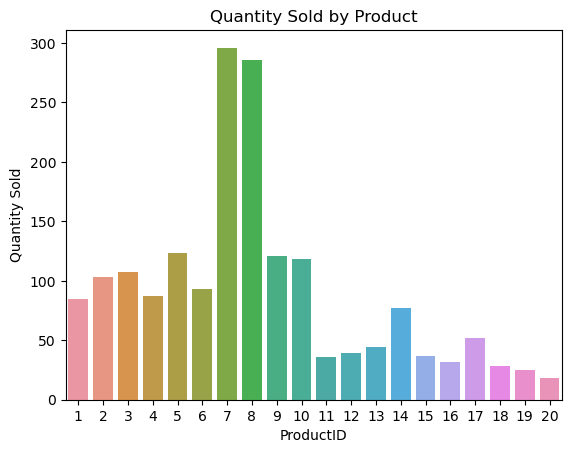

In [55]:
# 15. Create a bar plot that shows the Quanitity sold of each ProductID.


# Calculate the total Quantity by ProductID
product_quantity_df = orders_df[['ProductID', 'Quantity']].groupby(by='ProductID').sum().reset_index()

# Create the barplot
sns.barplot(data =product_quantity_df, 
            x= 'ProductID', 
            y= 'Quantity' )

plt.xlabel("ProductID")
plt.ylabel("Quantity Sold")
plt.title("Quantity Sold by Product")

Text(0.5, 1.0, 'Total Revenue vs Total Cost')

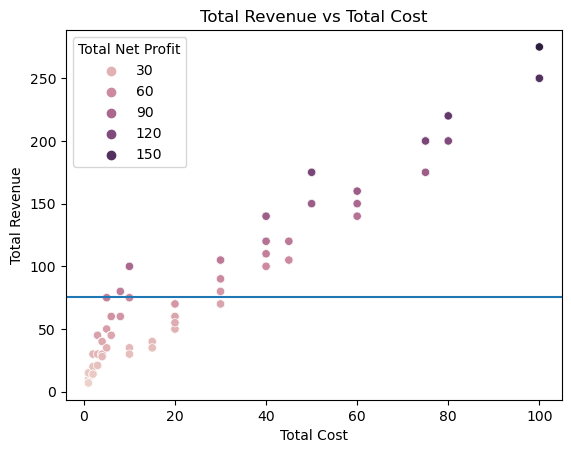

In [56]:
# 16. Create a scatterplot that plots Total Revenue and Total Cost. 
# The scatterplot should include:
# -hue that indicates the Total Net Profit of the order
# -a horizontal line that indicates the mean Total Revenue for comparison
# -all relevant labels to the plot and axis


sns.scatterplot(data=orders_df, 
            x='Total Cost', 
            y='Total Revenue',
            hue='Total Net Profit')

plt.axhline(y=np.nanmean(orders_df['Total Revenue']))
plt.xlabel("Total Cost")
plt.ylabel("Total Revenue")
plt.title("Total Revenue vs Total Cost")

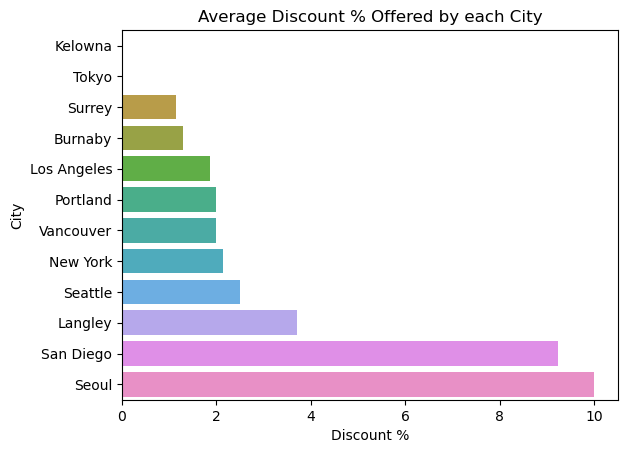

In [57]:
# 17. Create a horizontal barplot that shows the average Discount Pct for each City.


# Calculate the average Discount Pct by City. Sort the values by Discount Pct
city_discount_df = orders_df[['City','Discount Pct']].groupby(by='City').mean().sort_values(by='Discount Pct').reset_index()

# Create the barplot
sns.barplot(data=city_discount_df, 
            y='City', 
            x='Discount Pct', 
            orient='h') 

plt.xlabel("Discount %")
plt.ylabel("City")
plt.title("Average Discount % Offered by each City");

C:\Users\alikp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\alikp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Total Net Profit')

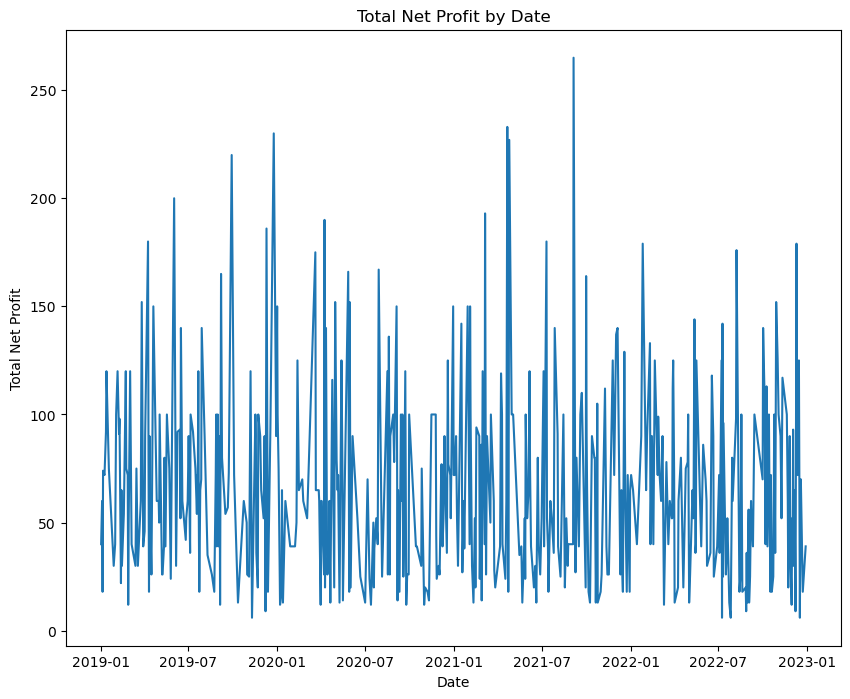

In [58]:
# 18. Create a lineplot that shows the Total Net Profit by Date

# Calculate Total Net Profit by Date
date_profit_df = orders_df[['Date','Total Net Profit']].groupby(by='Date').sum()

# Set the plot area
plt.figure(figsize=(10, 8))

# Create the lineplot
sns.lineplot(data = date_profit_df,
             x='Date',
             y='Total Net Profit')

plt.title("Total Net Profit by Date")
plt.xlabel("Date")
plt.ylabel("Total Net Profit")

<Axes: >

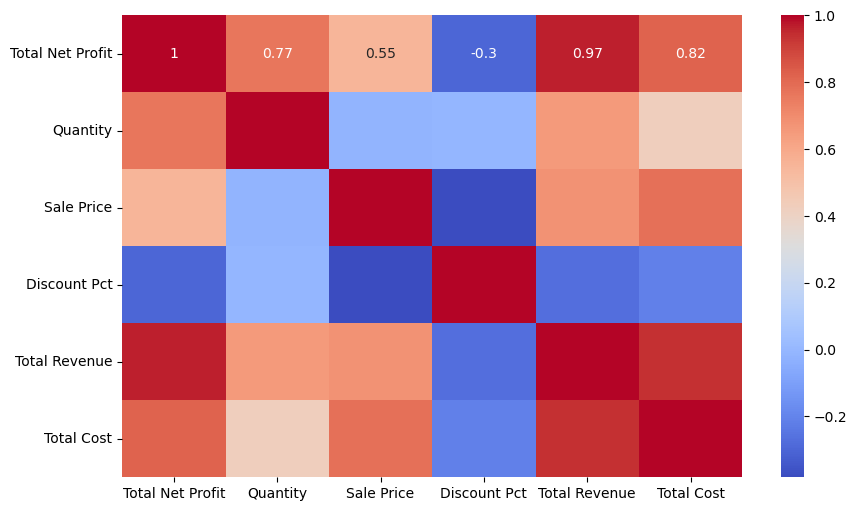

In [59]:
# 19. Create a heatmap to visualize the correlation of columns in order_df.

# Define the columns to include in correlation
corr_df = orders_df[['Total Net Profit', 'Quantity', 'Sale Price', 'Discount Pct','Total Revenue', 'Total Cost']]

# Calculate the correlation matrix
corr_matrix = corr_df.corr()

# Create the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

Text(0, 0.5, 'Quantity')

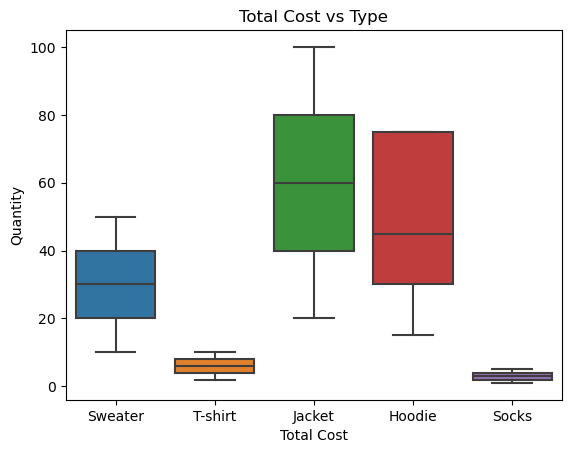

In [60]:
# 20a. Create a boxplot to identify any outliers in Total Revenue for each Type.

sns.boxplot(data=orders_df, 
            x='Type', 
            y='Total Cost')

plt.title("Total Cost vs Type")
plt.xlabel("Total Cost")
plt.ylabel("Quantity")

In [61]:
# 20b. Further explore the outliers identified in the visual and use the IQR rule to return the outlier rows from orders_df.

# Explore the descriptive statistics for the Type that contains the outliers
orders_df[orders_df['Type'] == 'Socks']['Total Revenue'].describe()

count    68.000000
mean     26.352941
std      16.200023
min       7.000000
25%      14.000000
50%      21.000000
75%      31.250000
max      75.000000
Name: Total Revenue, dtype: float64

In [62]:
# Calculate the IQR rule for this type to identify the outlier rows
q3 = 31.35
q1 = 14
IQR = q3 - q1
IQR_rule = 1.5*IQR
socks_df = orders_df[orders_df['Type'] == 'Socks']

# Return the outlier rows
socks_df[socks_df['Total Revenue'] >= (q3 + IQR_rule)]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,...,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit
19,12,2019,7,6,5,80,80,"Socks,Black",15,1,...,Vancouver,Standard,3.0,2019-07-06,0,15.0,14.0,75.0,5,70.0
133,12,2022,6,5,5,499,499,"Socks,Black",15,1,...,Vancouver,Standard,3.0,2022-06-05,0,15.0,14.0,75.0,5,70.0
462,12,2020,7,6,5,211,211,"Socks,Black",15,1,...,Langley,Standard,2.0,2020-07-06,0,15.0,14.0,75.0,5,70.0
468,12,2022,12,19,5,599,599,"Socks,Black",15,1,...,Langley,Standard,2.0,2022-12-19,0,15.0,14.0,75.0,5,70.0
